In [1]:
import kagglehub

path = kagglehub.dataset_download(
    "kaustubhdikshit/neu-surface-defect-database"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'neu-surface-defect-database' dataset.
Path to dataset files: /kaggle/input/neu-surface-defect-database


In [2]:
!pip install ultralytics opencv-python numpy tqdm scikit-fuzzy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.3 MB/s eta 0:00:00


In [3]:
import cv2
import numpy as np
import xml.etree.ElementTree as ET
from tqdm import tqdm
import glob
import random
import matplotlib.pyplot as plt


In [4]:

import os
NEU_ROOT = path+"/NEU-DET"


YOLO_ROOT = "dataset_yolo"


CLASSES = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

CLASS_MAP = {name: idx for idx, name in enumerate(CLASSES)}

for split in ["train", "val"]:
    os.makedirs(f"{YOLO_ROOT}/images/{split}", exist_ok=True)
    os.makedirs(f"{YOLO_ROOT}/labels/{split}", exist_ok=True)


In [5]:
def apply_clahe(img):
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    return clahe.apply(img)

def motion_blur(img, k=np.random.choice([3, 5, 6])):
    kernel = np.zeros((k, k))
    kernel[k // 2, :] = np.ones(k)
    kernel /= k
    return cv2.filter2D(img, -1, kernel)

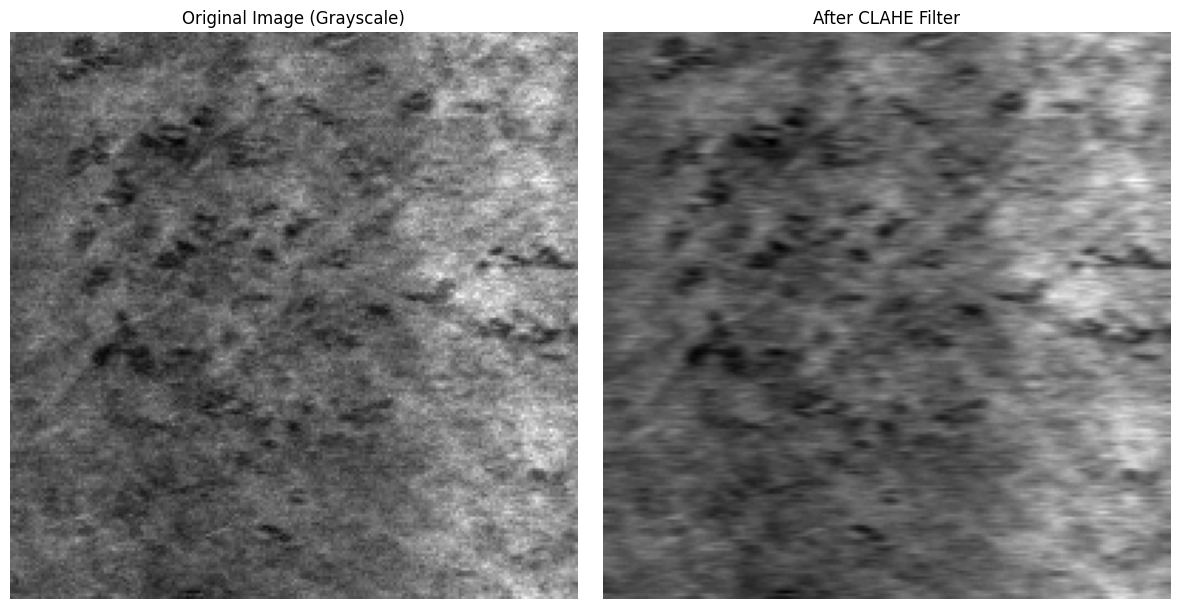

In [6]:
all_images = glob.glob(f"{NEU_ROOT}/train/images/*/rolled-in_scale_225.jpg")

if not all_images:
    print("Not found")
else:
    random_img_path = random.choice(all_images)
    original_img = cv2.imread(random_img_path, cv2.IMREAD_GRAYSCALE)
    processed_img = motion_blur(original_img)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title("Original Image (Grayscale)")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(processed_img, cmap='gray')
    plt.title("After CLAHE Filter")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [6]:
def voc_to_yolo(xml_path, img_w, img_h):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    labels = []

    for obj in root.findall("object"):
        cls_name = obj.find("name").text
        cls_id = CLASS_MAP[cls_name]

        b = obj.find("bndbox")
        xmin, ymin = float(b.find("xmin").text), float(b.find("ymin").text)
        xmax, ymax = float(b.find("xmax").text), float(b.find("ymax").text)

        xc = ((xmin + xmax) / 2) / img_w
        yc = ((ymin + ymax) / 2) / img_h
        w = (xmax - xmin) / img_w
        h = (ymax - ymin) / img_h

        labels.append(f"{cls_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")

    return labels

In [7]:
def process_train():
    img_root = f"{NEU_ROOT}/train/images"
    ann_root = f"{NEU_ROOT}/train/annotations"

    for cls in CLASSES:
        img_dir = f"{img_root}/{cls}"
        if not os.path.exists(img_dir): continue

        for img_name in tqdm(os.listdir(img_dir), desc=f"Processing {cls}"):
            img_path = os.path.join(img_dir, img_name)


            base_name = os.path.splitext(img_name)[0]
            xml_path = os.path.join(ann_root, f"{base_name}.xml")

            if not os.path.exists(xml_path):
                continue

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            h, w = img.shape

            img = apply_clahe(img)


            if np.random.rand() < 0.3:
                img = motion_blur(img, k=np.random.choice([3, 5, 7]))

            if np.random.rand() < 0.1:
                sigma = np.random.uniform(2, 10)
                noise = np.random.normal(0, sigma, (h, w)).astype(np.int16)
                img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

            cv2.imwrite(f"{YOLO_ROOT}/images/train/{base_name}.jpg", img)

            labels = voc_to_yolo(xml_path, w, h)
            with open(f"{YOLO_ROOT}/labels/train/{base_name}.txt", "w") as f:
                f.write("\n".join(labels))

In [8]:
def process_val():
    img_root = f"{NEU_ROOT}/validation/images"
    ann_root = f"{NEU_ROOT}/validation/annotations"

    for cls in CLASSES:
        img_dir = f"{img_root}/{cls}"
        if not os.path.exists(img_dir): continue

        for img_name in tqdm(os.listdir(img_dir), desc=f"Val {cls}"):
            img_path = os.path.join(img_dir, img_name)

            base_name = os.path.splitext(img_name)[0]
            xml_path = os.path.join(ann_root, f"{base_name}.xml")

            if not os.path.exists(xml_path):
                continue

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            h, w = img.shape

            img = apply_clahe(img)

            cv2.imwrite(f"{YOLO_ROOT}/images/val/{base_name}.jpg", img)

            labels = voc_to_yolo(xml_path, w, h)
            with open(f"{YOLO_ROOT}/labels/val/{base_name}.txt", "w") as f:
                f.write("\n".join(labels))

In [9]:
print(len(os.listdir(f"{NEU_ROOT}/train/annotations")))
print(len(os.listdir(f"{NEU_ROOT}/validation/annotations")))

1439
361


In [10]:
process_train()
process_val()
print("Dataset Prepared")

Val scratches: 100%|██████████| 60/60 [00:00<00:00, 98.25it/s]

Dataset Prepared


In [ ]:
import shutil

zip_file_name = "NEU_DET_YOLO_Ready"

shutil.make_archive(zip_file_name, 'zip', YOLO_ROOT)


print(f"✅ Saved {zip_file_name}.zip")
print(f" {os.path.getsize(zip_file_name + '.zip') / (1024*1024):.2f} MB")

✅ Saved NEU_DET_YOLO_Ready.zip
 36.00 MB


In [11]:
import os
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import os
import zipfile

drive_zip_path = '/content/drive/MyDrive/FINAL_Project/Dataset/NEU_DET_YOLO_Ready.zip'
local_zip_path = '/content/dataset_yolo.zip'
extract_to = YOLO_ROOT

if os.path.exists(drive_zip_path):
    !cp "{drive_zip_path}" {local_zip_path}

else:
    print("Not found")

if not os.path.exists(extract_to):
    os.makedirs(extract_to)

!unzip -q {local_zip_path} -d {extract_to}

!ls {extract_to}

replace dataset_yolo/images/train/inclusion_86.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
images	labels


In [13]:
with open("data.yaml", "w") as f:
    f.write("""
path: dataset_yolo
train: images/train
val: images/val

nc: 6
names:
  - crazing
  - inclusion
  - patches
  - pitted_surface
  - rolled-in_scale
  - scratches
""")


In [14]:
# ============================================================
# YOLO + FUZZY + PPO TRAINING PIPELINE
# ============================================================

# اگر در Colab هستی، این‌ها را نصب کن
!pip install -q ultralytics
!pip install -q stable-baselines3[extra]
!pip install -q gymnasium
!pip install -q scikit-fuzzy
!pip install -q opencv-python matplotlib tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 9.3 MB/s eta 0:00:00


In [15]:
import os
import cv2
import glob
import math
import time
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import deque

from ultralytics import YOLO

import gymnasium as gym
from gymnasium import spaces

import skfuzzy as fuzz
from skfuzzy import control as ctrl

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, CallbackList
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.evaluation import evaluate_policy

warnings.filterwarnings("ignore")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [25]:
import os
import random
import numpy as np

# =========================
# PATHS
# =========================
PROJECT_DIR = "/content/drive/MyDrive/FINAL_ProjectRc/Training_Results/YOLO_8n_v1/weights"
YOLO_WEIGHTS_PATH = os.path.join(PROJECT_DIR, "best.pt")
DATASET_ROOT = "/content/dataset_yolo"
PROJECT_DIR1 = "/content/drive/MyDrive/ppo-yolo8n"

os.makedirs(PROJECT_DIR1,exist_ok = True)

TRAIN_IMAGES_DIR = os.path.join(DATASET_ROOT, "images", "train")
VAL_IMAGES_DIR = os.path.join(DATASET_ROOT, "images", "val")
TRAIN_LABELS_DIR = os.path.join(DATASET_ROOT, "labels", "train")
VAL_LABELS_DIR = os.path.join(DATASET_ROOT, "labels", "val")

PPO_SAVE_DIR = os.path.join(PROJECT_DIR1, "PPO_Outputs")
BEST_MODEL_DIR = os.path.join(PPO_SAVE_DIR, "best_model")
FINAL_MODEL_PATH = os.path.join(PPO_SAVE_DIR, "ppo_final_model.zip")

# =========================
# RL HYPERPARAMETERS
# =========================
SEED = 42
INITIAL_SPEED = 0.5
MIN_SPEED = 0.1
MAX_SPEED = 1
SPEED_STEP = 0.1

TOTAL_TIMESTEPS = 15000
EVAL_FREQ = 1000
N_EVAL_EPISODES = 3
MAX_DETECTIONS = 20

# =========================
# REPRODUCIBILITY
# =========================
random.seed(SEED)
np.random.seed(SEED)

# =========================
# CREATE DIRS
# =========================
os.makedirs(PPO_SAVE_DIR, exist_ok=True)
os.makedirs(BEST_MODEL_DIR, exist_ok=True)

print("Setup done.")
print("YOLO_WEIGHTS_PATH:", YOLO_WEIGHTS_PATH)
print("TRAIN_IMAGES_DIR:", TRAIN_IMAGES_DIR)
print("VAL_IMAGES_DIR:", VAL_IMAGES_DIR)


Setup done.
YOLO_WEIGHTS_PATH: /content/drive/MyDrive/FINAL_ProjectRc/Training_Results/YOLO_8n_v1/weights/best.pt
TRAIN_IMAGES_DIR: /content/dataset_yolo/images/train
VAL_IMAGES_DIR: /content/dataset_yolo/images/val


In [17]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

class AdvancedFuzzyController:
    def __init__(self):
        self.risk_score = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'risk_score')
        self.confidence = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'confidence')
        self.speed_change = ctrl.Consequent(np.arange(-1, 1.01, 0.01), 'speed_change')

        self.risk_score['Low'] = fuzz.gaussmf(self.risk_score.universe, 0, 0.15)
        self.risk_score['Medium'] = fuzz.gaussmf(self.risk_score.universe, 0.5, 0.15)
        self.risk_score['High'] = fuzz.gaussmf(self.risk_score.universe, 1, 0.15)

        self.confidence['Low'] = fuzz.gaussmf(self.confidence.universe, 0, 0.15)
        self.confidence['Medium'] = fuzz.gaussmf(self.confidence.universe, 0.5, 0.15)
        self.confidence['High'] = fuzz.gaussmf(self.confidence.universe, 1, 0.15)

        self.speed_change['Brake'] = fuzz.gaussmf(self.speed_change.universe, -1, 0.25)
        self.speed_change['Maintain'] = fuzz.gaussmf(self.speed_change.universe, 0, 0.15)
        self.speed_change['Accelerate'] = fuzz.gaussmf(self.speed_change.universe, 1, 0.25)

        self.rules = [
            ctrl.Rule(self.risk_score['Low'] & self.confidence['High'], self.speed_change['Accelerate']),
            ctrl.Rule(self.risk_score['Low'] & self.confidence['Medium'], self.speed_change['Accelerate']),
            ctrl.Rule(self.risk_score['Low'] & self.confidence['Low'], self.speed_change['Maintain']),
            ctrl.Rule(self.risk_score['Medium'] & self.confidence['High'], self.speed_change['Brake']),
            ctrl.Rule(self.risk_score['Medium'] & self.confidence['Medium'], self.speed_change['Maintain']),
            ctrl.Rule(self.risk_score['Medium'] & self.confidence['Low'], self.speed_change['Maintain']),
            ctrl.Rule(self.risk_score['High'] & self.confidence['High'], self.speed_change['Brake']),
            ctrl.Rule(self.risk_score['High'] & self.confidence['Medium'], self.speed_change['Brake']),
            ctrl.Rule(self.risk_score['High'] & self.confidence['Low'], self.speed_change['Brake']),
        ]

        self.control_system = ctrl.ControlSystem(self.rules)
        self.simulation = ctrl.ControlSystemSimulation(self.control_system)

    def compute(self, risk_val, conf_val):
        self.simulation.input['risk_score'] = np.clip(risk_val, 0, 1)
        self.simulation.input['confidence'] = np.clip(conf_val, 0, 1)
        self.simulation.compute()
        return self.simulation.output['speed_change']

    def get_label(self, value):
        if value < -0.1:
            return "BRAKE"
        elif value > 0.1:
            return "ACCELERATE"
        return "MAINTAIN"


In [18]:
from ultralytics import YOLO

yolo_model = YOLO(YOLO_WEIGHTS_PATH)
fuzzy_brain = AdvancedFuzzyController()

print("YOLO and fuzzy controller loaded.")


YOLO and fuzzy controller loaded.


In [19]:
CLASSES = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

COLORS = {
    0: (255, 0, 0),
    1: (0, 255, 0),
    2: (0, 0, 255),
    3: (255, 255, 0),
    4: (255, 0, 255),
    5: (0, 255, 255),
}

RISK_FACTORS = {
    0: 1.0,  # crazing
    1: 0.9,  # inclusion
    2: 0.6,  # patches
    3: 0.8,  # pitted_surface
    4: 0.5,  # rolled-in_scale
    5: 0.2   # scratches
}

def calculate_weighted_risk(results, img_shape):
    h, w = img_shape[:2]
    total_pixels = h * w
    total_weighted_risk = 0.0
    confidences = []

    if results.boxes is None or len(results.boxes) == 0:
        return 0.0, 0.0

    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        box_area = max(0, (x2 - x1)) * max(0, (y2 - y1))
        normalized_area = box_area / total_pixels

        cls_id = int(box.cls[0].cpu().numpy())
        risk_factor = RISK_FACTORS.get(cls_id, 0.5)

        total_weighted_risk += (normalized_area * risk_factor) * 10.0
        confidences.append(float(box.conf[0].cpu().numpy()))

    mean_conf = sum(confidences) / len(confidences) if confidences else 0.0
    return min(total_weighted_risk, 1.0), mean_conf

def draw_gt(img, label_path):
    h, w, _ = img.shape
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                cls, x, y, nw, nh = map(float, line.split())
                x1 = int((x - nw / 2) * w)
                y1 = int((y - nh / 2) * h)
                x2 = int((x + nw / 2) * w)
                y2 = int((y + nh / 2) * h)

                cls_id = int(cls)
                class_name = CLASSES[cls_id] if cls_id < len(CLASSES) else str(cls_id)

                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 255), 2)
                cv2.putText(
                    img,
                    f"GT: {class_name}",
                    (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255, 255, 255),
                    2
                )
    return img

def draw_pred(img, results):
    if results.boxes is None:
        return img

    for box in results.boxes:
        c = int(box.cls[0].cpu().numpy())
        conf = float(box.conf[0].cpu().numpy())
        xyxy = box.xyxy[0].cpu().numpy().astype(int)
        color = COLORS.get(c, (200, 200, 200))
        class_name = CLASSES[c] if c < len(CLASSES) else str(c)

        cv2.rectangle(img, (xyxy[0], xyxy[1]), (xyxy[2], xyxy[3]), color, 2)
        cv2.putText(
            img,
            f"{class_name} {conf:.2f}",
            (xyxy[0], max(xyxy[1] - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )
    return img


In [29]:
import random

FUZZY_TEST_SAVE_DIR = "/content/drive/MyDrive/ppo-yolo8nv1/Fuzzy_Test_Outputs"
os.makedirs(FUZZY_TEST_SAVE_DIR, exist_ok=True)

fuzzy_brain = AdvancedFuzzyController()

scenarios = [
    {"area": 0.85, "conf": 0.90, "name": "Scenario1_HighRisk"},
    {"area": 0.10, "conf": 0.85, "name": "Scenario2_LowRisk"},
    {"area": 0.50, "conf": 0.30, "name": "Scenario3_Ambiguous"}
]

for sc in scenarios:
    res = fuzzy_brain.compute(sc["area"], sc["conf"])
    print(f"Testing {sc['name']}: Risk={sc['area']}, Conf={sc['conf']} --> Speed Change={res:.2f}")



all_images = [f for f in os.listdir(VAL_IMAGES_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
sample_images = random.sample(all_images, min(3, len(all_images)))

for img_name in sample_images:
    img_path = os.path.join(VAL_IMAGES_DIR, img_name)
    lbl_path = os.path.join(VAL_LABELS_DIR, os.path.splitext(img_name)[0] + ".txt")

    original_img = cv2.imread(img_path)
    if original_img is None:
        continue

    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    results = yolo_model(img_path, conf=0.25, verbose=False)[0]

    calc_risk, calc_conf = calculate_weighted_risk(results, original_img.shape)
    fuzzy_output = fuzzy_brain.compute(calc_risk, calc_conf)

    gt_img = draw_gt(original_img.copy(), lbl_path)
    pred_img = draw_pred(original_img.copy(), results)

    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 2)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(gt_img)
    ax1.set_title(f"Ground Truth: {img_name}", fontsize=12, fontweight='bold')
    ax1.axis("off")

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(pred_img)
    ax2.set_title("YOLOv8 Detection", fontsize=12, fontweight='bold')
    ax2.axis("off")

    ax3 = fig.add_subplot(gs[1, 0])
    ax3.axis("off")

    decision_text = fuzzy_brain.get_label(fuzzy_output)
    if decision_text == "BRAKE":
        decision_text = "BRAKE (Slow Down)"

    text_info = (
        f"--- Fuzzy Input Analysis ---\n\n"
        f"1. Weighted Risk Score: {calc_risk:.3f} (0 to 1)\n"
        f"2. Mean Confidence:     {calc_conf*100:.1f}%\n\n"
        f"--- Fuzzy Output Decision ---\n\n"
        f"SPEED CHANGE FACTOR:    {fuzzy_output:.3f}\n"
        f"Decision: {decision_text}"
    )

    ax3.text(
        0.1, 0.5, text_info,
        fontsize=14, va='center', ha='left',
        bbox=dict(boxstyle="round,pad=0.5", fc="#f0f0f0", ec="black", alpha=0.9)
    )

    ax4 = fig.add_subplot(gs[1, 1])
    x = fuzzy_brain.speed_change.universe
    mfs = fuzzy_brain.speed_change.terms

    for label, term in mfs.items():
        ax4.plot(x, term.mf, label=label, linewidth=1.5)
        ax4.fill_between(x, 0, term.mf, alpha=0.1)

    ax4.vlines(fuzzy_output, 0, 1, colors='r', linestyles='dashed', linewidth=3, label='Result')
    ax4.set_title("Fuzzy Speed Control Logic", fontsize=12, fontweight='bold')
    ax4.legend(loc='upper right')
    ax4.grid(True, alpha=0.3)

    save_path = os.path.join(FUZZY_TEST_SAVE_DIR, img_name)
    plt.savefig(save_path, bbox_inches='tight', dpi=100)
    plt.close(fig)

    print(f"Saved: {save_path}")

print(f"Output plots path:\n{FUZZY_TEST_SAVE_DIR}")


Testing Scenario1_HighRisk: Risk=0.85, Conf=0.9 --> Speed Change=-0.71
Testing Scenario2_LowRisk: Risk=0.1, Conf=0.85 --> Speed Change=0.63
Testing Scenario3_Ambiguous: Risk=0.5, Conf=0.3 --> Speed Change=0.00
Saved: /content/drive/MyDrive/ppo-yolo8nv1/Fuzzy_Test_Outputs/scratches_270.jpg
Saved: /content/drive/MyDrive/ppo-yolo8nv1/Fuzzy_Test_Outputs/inclusion_277.jpg
Saved: /content/drive/MyDrive/ppo-yolo8nv1/Fuzzy_Test_Outputs/inclusion_253.jpg
Output plots path:
/content/drive/MyDrive/ppo-yolo8nv1/Fuzzy_Test_Outputs


In [20]:
def extract_yolo_features(image_path, current_speed, yolo_model):
    img = cv2.imread(image_path)
    if img is None:
        return {
            "max_risk_score": 0.0,
            "mean_confidence": 0.0,
            "defect_count": 0,
            "closest_defect_dist": 1.0
        }

    h, w = img.shape[:2]
    img_blurred = apply_motion_blur(img.copy(), current_speed)
    results = yolo_model(img_blurred, conf=0.25, verbose=False)[0]

    if results.boxes is None or len(results.boxes) == 0:
        return {
            "max_risk_score": 0.0,
            "mean_confidence": 0.0,
            "defect_count": 0,
            "closest_defect_dist": 1.0
        }

    total_pixels = float(h * w)
    confidences = []
    risk_scores = []
    center_distances = []

    img_center_x = w / 2.0
    img_center_y = h / 2.0
    max_possible_dist = np.sqrt(img_center_x**2 + img_center_y**2)

    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        cls_id = int(box.cls[0].cpu().numpy())
        conf = float(box.conf[0].cpu().numpy())

        box_area = max(0.0, (x2 - x1)) * max(0.0, (y2 - y1))
        normalized_area = box_area / total_pixels
        risk_factor = RISK_FACTORS.get(cls_id, 0.5)
        risk_score = min(normalized_area * risk_factor * 10.0, 1.0)

        box_cx = (x1 + x2) / 2.0
        box_cy = (y1 + y2) / 2.0
        dist = np.sqrt((box_cx - img_center_x)**2 + (box_cy - img_center_y)**2)
        normalized_dist = dist / max_possible_dist if max_possible_dist > 0 else 1.0

        confidences.append(conf)
        risk_scores.append(risk_score)
        center_distances.append(normalized_dist)

    return {
        "max_risk_score": float(max(risk_scores)) if risk_scores else 0.0,
        "mean_confidence": float(np.mean(confidences)) if confidences else 0.0,
        "defect_count": int(len(results.boxes)),
        "closest_defect_dist": float(min(center_distances)) if center_distances else 1.0
    }


In [21]:
class DefectSpeedEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, image_paths, yolo_model, fuzzy_controller):
        super().__init__()

        self.image_paths = image_paths
        self.yolo_model = yolo_model
        self.fuzzy_controller = fuzzy_controller

        self.current_idx = 0
        self.current_speed = INITIAL_SPEED
        self.max_steps = len(self.image_paths)
        self.step_count = 0

        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, MIN_SPEED, 0.0, 0.0, -1.0], dtype=np.float32),
            high=np.array([1.0, 1.0, MAX_SPEED, 1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32
        )

        self.action_space = spaces.Discrete(3)

    def _get_observation(self):
        image_path = self.image_paths[self.current_idx]
        features = extract_yolo_features(image_path, self.current_speed, self.yolo_model)

        risk_score = float(features["max_risk_score"])
        mean_conf = float(features["mean_confidence"])
        defect_count = min(float(features["defect_count"]) / float(MAX_DETECTIONS), 1.0)
        closest_dist = float(features["closest_defect_dist"])

        fuzzy_output = float(self.fuzzy_controller.compute(risk_score, mean_conf))

        obs = np.array([
            risk_score,
            mean_conf,
            self.current_speed,
            defect_count,
            closest_dist,
            fuzzy_output
        ], dtype=np.float32)

        return obs, features, fuzzy_output

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_idx = 0
        self.step_count = 0
        self.current_speed = INITIAL_SPEED
        obs, _, _ = self._get_observation()
        return obs, {}

    def step(self, action):
        obs, features, fuzzy_output = self._get_observation()

        prev_speed = self.current_speed
        risk_score = float(features["max_risk_score"])
        mean_conf = float(features["mean_confidence"])

        # action -> speed delta
        if action == 0:
            agent_delta = -SPEED_STEP
        elif action == 1:
            agent_delta = 0.0
        else:
            agent_delta = SPEED_STEP

        self.current_speed = float(np.clip(prev_speed + agent_delta, MIN_SPEED, MAX_SPEED))

        # fuzzy output -> fuzzy action
        if fuzzy_output < -0.1:
            fuzzy_action = 0
        elif fuzzy_output > 0.1:
            fuzzy_action = 2
        else:
            fuzzy_action = 1

        reward = 0.0

        # 1) fuzzy alignment (low weight)
        reward += 0.15 if action == fuzzy_action else -0.05

        # 2) soft rule-based shaping (weaker than before)
        if risk_score > 0.7:
            reward += 1.2 if action == 0 else (-1.2 if action == 2 else 0.2)
        elif risk_score < 0.3:
            reward += 0.8 if action == 2 else (-0.6 if action == 0 else 0.1)
        else:
            if action == 1:
                reward += 0.4

        # 3) confidence bonus
        reward += 0.3 * mean_conf

        # 4) continuous speed-risk reward
        reward += 0.5 * self.current_speed * (1.0 - risk_score)
        reward -= 1.5 * risk_score * self.current_speed

        # 5) smoothness penalty
        reward -= 0.3 * abs(self.current_speed - prev_speed)

        self.current_idx += 1
        self.step_count += 1

        terminated = self.current_idx >= self.max_steps
        truncated = False

        if not terminated:
            next_obs, _, _ = self._get_observation()
        else:
            next_obs = obs

        info = {
            "risk_score": risk_score,
            "mean_confidence": mean_conf,
            "fuzzy_output": fuzzy_output,
            "fuzzy_action": fuzzy_action,
            "action": action,
            "current_speed": self.current_speed,
            "reward": reward
        }

        return next_obs, reward, terminated, truncated, info


    def render(self):
        pass


In [22]:
def apply_motion_blur(image, speed):
    factor = 20
    kernel_size = int(max(1, speed * factor))

    if kernel_size < 2:
        return image

    if kernel_size % 2 == 0:
        kernel_size += 1

    kernel_motion_blur = np.zeros((kernel_size, kernel_size), dtype=np.float32)
    kernel_motion_blur[kernel_size // 2, :] = np.ones(kernel_size, dtype=np.float32)
    kernel_motion_blur /= kernel_size

    return cv2.filter2D(image, -1, kernel_motion_blur)


In [23]:
class ManualEvalCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=2000, n_eval_episodes=5, best_model_dir="./best_model", verbose=1):
        super().__init__(verbose)
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.best_model_dir = best_model_dir
        self.best_mean_reward = -np.inf

        os.makedirs(self.best_model_dir, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0:
            rewards = []

            for _ in range(self.n_eval_episodes):
                obs = self.eval_env.reset()[0]
                done = False
                truncated = False
                total_reward = 0.0

                while not done and not truncated:
                    action, _ = self.model.predict(obs, deterministic=True)
                    obs, reward, done, truncated, info = self.eval_env.step(action)
                    total_reward += reward

                rewards.append(total_reward)

            mean_reward = float(np.mean(rewards))

            if self.verbose:
                print(f"[Eval] Step={self.n_calls} | Mean Reward={mean_reward:.3f}")

            if mean_reward > self.best_mean_reward:
                self.best_mean_reward = mean_reward
                save_path = os.path.join(self.best_model_dir, "best_model")
                self.model.save(save_path)

                if self.verbose:
                    print(f"New best model saved at: {save_path}")

        return True


In [26]:
def list_images(img_dir):
    exts = (".jpg", ".jpeg", ".png")
    paths = [
        os.path.join(img_dir, f)
        for f in os.listdir(img_dir)
        if f.lower().endswith(exts)
    ]
    return sorted(paths)

train_image_paths = list_images(TRAIN_IMAGES_DIR)
val_image_paths   = list_images(VAL_IMAGES_DIR)

assert len(train_image_paths) > 0, "No train images found!"
assert len(val_image_paths) > 0, "No val images found!"


In [35]:
# =========================
# BUILD TRAIN / VAL ENVS
# =========================

train_env = DummyVecEnv([
    lambda: Monitor(DefectSpeedEnv(train_image_paths, yolo_model, AdvancedFuzzyController()))
])

eval_env = DefectSpeedEnv(val_image_paths,yolo_model, AdvancedFuzzyController())

# =========================
# CALLBACK
# =========================
manual_eval_callback = ManualEvalCallback(
    eval_env=eval_env,
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES,
    best_model_dir=BEST_MODEL_DIR,
    verbose=1
)

# =========================
# PPO MODEL
# =========================
ppo_model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=1e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=8,
    gamma=0.985,
    gae_lambda=0.95,
    clip_range=0.15,
    ent_coef=0.10,
    vf_coef=0.6,
    max_grad_norm=0.5,
    policy_kwargs=dict(net_arch=dict(pi=[64, 64], vf=[128, 128])),
    verbose=1,
    tensorboard_log=os.path.join(PPO_SAVE_DIR, "tensorboard_logs"),
    seed=SEED
)



# =========================
# TRAIN
# =========================
ppo_model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=manual_eval_callback
)

# =========================
# SAVE FINAL MODEL
# =========================
ppo_model.save(FINAL_MODEL_PATH)
print(f"Final PPO model saved at: {FINAL_MODEL_PATH}")


Using cuda device
Logging to /content/drive/MyDrive/ppo-yolo8n/PPO_Outputs/tensorboard_logs/PPO_1
[Eval] Step=1000 | Mean Reward=-46.604
New best model saved at: /content/drive/MyDrive/ppo-yolo8n/PPO_Outputs/best_model/best_model
-----------------------------
| time/              |      |
|    fps             | 15   |
|    iterations      | 1    |
|    time_elapsed    | 64   |
|    total_timesteps | 1024 |
-----------------------------
[Eval] Step=2000 | Mean Reward=365.686
New best model saved at: /content/drive/MyDrive/ppo-yolo8n/PPO_Outputs/best_model/best_model
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.44e+03    |
|    ep_rew_mean          | -229        |
| time/                   |             |
|    fps                  | 16          |
|    iterations           | 2           |
|    time_elapsed         | 127         |
|    total_timesteps      | 2048        |
| train/                  |             |
|    app

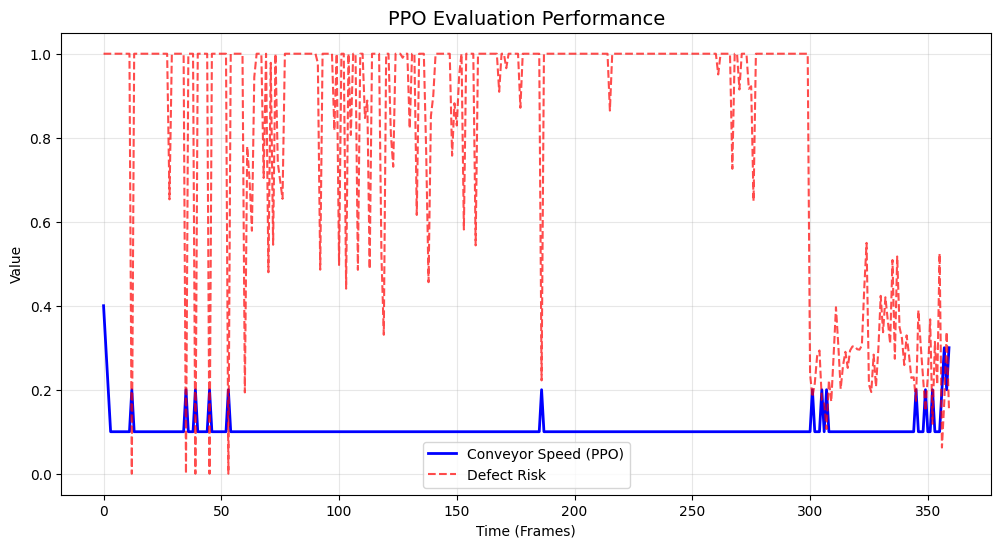

Video saved to: /content/drive/MyDrive/ppo-yolo8n/ppo_evaluation_video.mp4
Plot saved to: /content/drive/MyDrive/ppo-yolo8n/ppo_performance_plot.png


In [27]:
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from ultralytics import YOLO

# =========================
# Paths & Setup
# =========================
PROJECT_DIR = "/content/drive/MyDrive/FINAL_ProjectRc/Training_Results/YOLO_8n_v1/weights"
YOLO_WEIGHTS_PATH = os.path.join(PROJECT_DIR, "best.pt")
PPO_MODEL_PATH = "/content/drive/MyDrive/ppo-yolo8n/PPO_Outputs/best_model/best_model.zip"
PROJECT_DIR3 = "/content/drive/MyDrive/ppo-yolo8n"
VIDEO_OUTPUT_PATH = os.path.join(PROJECT_DIR3, "ppo_evaluation_video.mp4")
SAVE_PLOT_PATH = os.path.join(PROJECT_DIR3, "ppo_performance_plot.png")
VAL_IMAGES_DIR = "/content/dataset_yolo/images/val"

yolo_model = YOLO(YOLO_WEIGHTS_PATH)
ppo_model = PPO.load(PPO_MODEL_PATH)
fuzzy_brain = AdvancedFuzzyController()

# Collect images
image_paths = sorted(
    glob.glob(os.path.join(VAL_IMAGES_DIR, "**", "*.jpg"), recursive=True) +
    glob.glob(os.path.join(VAL_IMAGES_DIR, "**", "*.jpeg"), recursive=True) +
    glob.glob(os.path.join(VAL_IMAGES_DIR, "**", "*.png"), recursive=True)
)

if len(image_paths) == 0:
    raise RuntimeError(f"No images found in: {VAL_IMAGES_DIR}")

# =========================
# Helpers
# =========================
def draw_detections(frame, results, names=None):
    if results.boxes is None or len(results.boxes) == 0:
        return frame
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        conf = float(box.conf[0].item()) if box.conf is not None else 0.0
        cls_id = int(box.cls[0].item()) if box.cls is not None else -1
        name = names[cls_id] if names and cls_id in names else str(cls_id)
        color = (0, 255, 0) if conf >= 0.5 else (0, 255, 255)
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(frame, f"{name} {conf:.2f}", (x1, max(20, y1 - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    return frame

def make_frame(image_path, current_speed, action, risk_score, mean_conf, yolo_model):
    img = cv2.imread(image_path)
    if img is None:
        img = np.zeros((480, 640, 3), dtype=np.uint8)

    frame = apply_motion_blur(img.copy(), current_speed)
    results = yolo_model(frame, conf=0.25, verbose=False)[0]
    frame = draw_detections(frame, results, names=yolo_model.names)

    h, w = frame.shape[:2]
    overlay = frame.copy()
    cv2.rectangle(overlay, (0, 0), (320, 100), (0, 0, 0), -1)
    frame = cv2.addWeighted(overlay, 0.6, frame, 0.4, 0)

    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(frame, f"SPEED: {current_speed:.2f}", (20, 30), font, 0.6, (0, 255, 255), 2)
    cv2.putText(frame, f"RISK: {risk_score:.3f}", (20, 60), font, 0.6, (255, 0, 255), 2)


    return frame

def plot_performance(speed_log, risk_log, save_path):
    plt.figure(figsize=(12, 6))
    plt.plot(speed_log, label='Conveyor Speed (PPO)', color='blue', linewidth=2)
    plt.plot(risk_log, label='Defect Risk', color='red', linestyle='--', alpha=0.7)
    plt.title("PPO Evaluation Performance", fontsize=14)
    plt.xlabel("Time (Frames)")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(save_path)
    plt.show()

# =========================
# Video Loop & Data Logger
# =========================
def create_evaluation_video(env, model, output_path, fps=6, max_steps=None):
    obs, _ = env.reset()
    frames = []
    speed_log = []
    risk_log = []
    done, step = False, 0

    while not done:
        current_idx = env.current_idx
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Logging Data
        speed = float(info.get("current_speed", 0.0))
        risk = float(info.get("risk_score", 0.0))
        speed_log.append(speed)
        risk_log.append(risk)

        frame = make_frame(
            image_path=env.image_paths[current_idx],
            current_speed=speed,
            action=int(action),
            risk_score=risk,
            mean_conf=float(info.get("mean_confidence", 0.0)),
            yolo_model=env.yolo_model
        )
        frames.append(frame)

        step += 1
        if max_steps and step >= max_steps: break

    if frames:
        height, width, _ = frames[0].shape
        writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))
        for fr in frames: writer.write(fr)
        writer.release()

    return output_path, speed_log, risk_log

# =========================
# Execution
# =========================
env = DefectSpeedEnv(image_paths=image_paths, yolo_model=yolo_model, fuzzy_controller=fuzzy_brain)

# Run process
video_path, s_log, r_log = create_evaluation_video(env, ppo_model, VIDEO_OUTPUT_PATH, fps=6)
plot_performance(s_log, r_log, SAVE_PLOT_PATH)

print("Video saved to:", video_path)
print("Plot saved to:", SAVE_PLOT_PATH)
